## Study of differential state-space model Diff-UMamba in out-of-distribution dynamics with Lorenz Attractor via Comparison with nn-UNet and UMamba

The main motivation of the current study is envistigating the capacity of the recently proposed Diff-UMamba with a Noise Reduction Module (NRM) to **generalize distribution shift**. In order to do that, we compare Diff-UMamba with U-Mamba (no NRM module - no noise suppresion) and the baseline model nn-UNet (no Mamba block - no long-range modeling). These models were built within Medical Image Analysis (MedIA), for which even well-trained models are struggling when deployed in different medical sites, modalities, and sequences, known as a domain shift issue. 

There are three known levels to address this issue *(Niu, 2024)*: 
1. Data manipulation level
2. Feature representation level 
3. Model training level

Current setup is laying under the Model training level. Being itself not the model proposed to specifically adress the domain shift issue, it would still be interesting to investigate this property of both Mamba block and the improved Differential Mamba block *(Jain, 2026)* built on the baseline nnU-Net. 

**nnU-Net**

The baseline nnU-Net is an automated deep learning framework for biomedical image segmentation, which uses a U-shaped encoder to extract image features and a decoder to reconstruct the mask, linked by skip connections. nnU-Net stands for no-new-U-Net, where U-Net is a convolutional neural network designed for semantic image segmentation and the "no-new" is the optimized version of it *(Isensee, 2021)*. 

![image](./0_PkMBRPa77g-ICW5e.webp)

*Figure 1. nnU-Net workflow*

**UMamba-Bot**

UMamba-Bot is a medical image segmentation model built upon the nnU-Net framework. It adds Selective State Space Model (Mamba) at the bottleneck of the network *(Ma, 2024)*.

The State Space Models overcome the problem with which traditional Transformers often struggle - short-term memory. And the Selective State Space Models, such as Mamba, are working even smarter by not only keeping the input in the memory but also selecting how important the input is and "deserves" to be remembered. based  memory updates formulas are shown below. 

- Hidden state update: $$h_t = A(x_t)h_{t-1} + B(x_t)x_t$$

The Matrix $A(x_t)$ (The Context Filter): It determines how much of the old memory $(h_{t-1})$ to keep or forget; depends directly on the current input. 

The Matrix $B(x_t)$ (The Input Gate): This matrix determines *how much weight* to give to the new, incoming input data.

In traditional State Space Models (SSMs), $A$ and $B$ are static matrices that stay the same for every token. In Mamba, making them functions of $x_{t}$ allows the model to selectively remember or ignore data based on the content.

- Output prediciton: $$y_t = Ch_t$$

The Matrix $C$ is a projection matrix that decodes the compressed information inside the hidden state into the final feature representation $(y_{t})$.

![image](./fig1-network.png)

*Figure 2. UMamba-bot workflow*

**Diff-UMamba**

Diff-UMamba is a recently proposed improved model built upon UMamba *(Jain, 2026)*, the main goal of their work was improving the model's perfornace under limited data regime.  The Diff-UMamba incorporates Noise Reduction Module, which was inspired by the Differential Transformer architecture *(Ye, 2025)*. Instead of processing a single mainstream of attention, it splits the internal feature mappings into two parallel streams: one captures the primary features (signal + background noise) and the other captures the redundant or noisy background patterns. By subtracting them, the module cancels out the common noise.

![image](./diff_mamba.png)

*Figure 3. An overview of the Diff-UMamba.*

In the original paper *(Jain, 2026)* authors focused on the generalization of the proposed framework, while never adressing explicitly the OOD capabilities of it. The foundational work on Diff-UMamba demonstrated the framework’s potential, however, persisnently remaining challenge in megical image segmentation, namely, robustness under out-of-distribution conditions, needs to be addressed for the practical reasons. To address this, we leverage the Lorenz attractor to construct a controlled, synthetic dataset that allows for the systematic exploration of generalization under diverse dynamical regimes.

Sources:

1. E. Lorenz: **Deterministic nonperiodic flow.**, J. Atmos. Sci. 20(2) 1963.
2. Niu, Z., Ouyang, S., Xie, S., Chen, Y., & Lin, L. (2024). **A Survey on Domain Generalization for Medical Image Analysis.** ArXiv, abs/2402.05035.
3. Dhruv Jain, Romain Modzelewski, Romain Hérault, Clement Chatelain, Eva Torfeh, Sebastien Thureau, **Differential-UMamba: Rethinking tumor segmentation under limited data scenarios**, Biomedical Signal Processing and Control, Volume 120, Part C, 2026, 110163, ISSN 1746-8094, https://doi.org/10.1016/j.bspc.2026.110163.
4. Ma, J., Li, F., & Wang, B. (2024). **U-Mamba: Enhancing Long-range Dependency for Biomedical Image Segmentation.** ArXiv, abs/2401.04722.
5. Isensee, F., Jaeger, P.F., Kohl, S.A.A. et al. **nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation.** Nat Methods 18, 203–211 (2021).
6. Isensee, F. et al. (2024). **nnU-Net Revisited: A Call for Rigorous Validation in 3D Medical Image Segmentation.** In: Linguraru, M.G., et al. Medical Image Computing and Computer Assisted Intervention – MICCAI 2024. MICCAI 2024. Lecture Notes in Computer Science, vol 15009. Springer, Cham. https://doi.org/10.1007/978-3-031-72114-4_47.
7. Han B, Chu F, Shi L, Hu C, Wang S, Wang Z, Bai B, Zhao K, Wang M, Liu Z, Zhao Y, Qu J. **Automated segmentation of esophageal squamous cell carcinoma in contrast-enhanced free-breathing 3D-GRE: a comparative study of UNet, nnUNet, and UMamba for tumor delineation.** BMC Med Imaging. 2025 Nov 11;25(1):457. doi: 10.1186/s12880-025-02011-6. PMID: 41219837; PMCID: PMC12606847.
8. Ye, T., Dong, L., Xia, Y., Sun, Y., Zhu, Y., Huang, G., & Wei, F. (2025). **Differential Transformer.** In International Conference on Learning Representations (ICLR). https://arxiv.org/abs/2410.05258

In [1]:
import os
import sys
import numpy as np
from scipy.integrate import solve_ivp
import nibabel as nib
import os, json, shutil
import torch

import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

import glob
from collections import defaultdict

In [2]:
GRID = 64
GLOBAL_BOUNDS = np.array([[-30, -35, 0], [30, 35, 400]], dtype=np.float32)

### **Dataset Generation**

#### **Define Dataset**

Based on classical formulation of the Lorenz attractor, we can define functions, which are describing two butterflies according to the following formulas (Lorenz, 1963):

$dx = σ(y-x)$

$dy = x (ρ - z) - y$

$dz = x y - β z$

In [3]:
def lorenz_rhs(t, state, sigma, rho, beta):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

In [4]:
def simulate_lorenz(sigma, rho, beta, x0, t_span=(0, 30), dt=0.01, discard=5.0):
    
    t_eval = np.arange(t_span[0], t_span[1], dt)
    sol = solve_ivp(
        lorenz_rhs, t_span, x0, args=(sigma, rho, beta),
        t_eval=t_eval, method='RK45', rtol=1e-7, atol=1e-9
    )
    keep = sol.t >= discard
    traj = sol.y[:, keep].T  
    if traj.shape[0] < 100 or not np.all(np.isfinite(traj)):
        return None  

    return traj

Then, in order to match the input format for the baseline nn-UNet architecture, which is the same for all three networks that we are going to explore, we need to transform the trajectories into 3D images.

nnU-Net, U-Mamba, and Diff-UMamba are all built to consume 3D (or 2D) **voxel grids with integer voxel-wise segmentation labels** — the standard input representation for medical image segmentation (CT/MRI volumes plus organ/lesion masks). U-Mamba and Diff-UMamba do not define their own data pipeline or input format at all; so we need to prepare data exactly as nnU-Net expects (which is good because we wiil not have any performance difference from differing data pipelines).

Since a Lorenz trajectory is a continuous, variable-length, unstructured point cloud in ℝ³ (a sequence of (x, y, z) states sampled at fixed time steps). Therefore, it first has to be converted into a fixed-shape, voxel-grid image with an accompanying integer label volume.

In [5]:
def voxelize(traj, grid, bounds):
    """
    Returns:
      density   : normalized visitation-count volume (channel 0000)
      speed_map : normalized mean local speed per voxel (channel 0001)
      idx       : per-timestep voxel index, reused for labeling
    """
    idx = ((traj - bounds[0]) / (bounds[1] - bounds[0]) * grid).astype(int)
    idx = np.clip(idx, 0, grid - 1)

    density   = np.zeros((grid,)*3, dtype=np.float32)
    speed_acc = np.zeros((grid,)*3, dtype=np.float32)
    speed_cnt = np.zeros((grid,)*3, dtype=np.float32)

    vel = np.gradient(traj, axis=0)
    speed = np.linalg.norm(vel, axis=1)

    for (i, j, k), s in zip(idx, speed):
        density[i, j, k]   += 1
        speed_acc[i, j, k] += s
        speed_cnt[i, j, k] += 1

    speed_map = np.divide(speed_acc, speed_cnt,
                           out=np.zeros_like(speed_acc), where=speed_cnt > 0)
    density   = density   / (density.max()   + 1e-8)
    speed_map = speed_map / (speed_map.max() + 1e-8)
    return density, speed_map, idx

Each occupied voxel is labeled by which "wing" of the attractor it belongs to (sign of the x-coordinate at that location: **right_wing=1**, **left_wing=2**), with unoccupied voxels labeled **background=0** and voxels visited by trajectory points from both wings (i.e. near the crossover region) labeled **transition=3**. 

In [6]:
def make_labels(idx, bounds, grid):
    """
    0 = background (never visited)
    1 = right wing  (x >= 0 lobe)
    2 = left wing   (x <  0 lobe)
    3 = transition  (voxel visited by trajectory points from BOTH lobes,
                     e.g. near the central saddle where switches happen)
    """
    label = np.zeros((grid,)*3, dtype=np.uint8)
    x_centers = (idx[:, 0] + 0.5) / grid * (bounds[1,0] - bounds[0,0]) + bounds[0,0]
    wing = np.where(x_centers >= 0, 1, 2)

    for (i, j, k), w in zip(idx, wing):
        if label[i, j, k] == 0:
            label[i, j, k] = w
        elif label[i, j, k] != w:
            label[i, j, k] = 3
    return label

It is important to apply the transformation identically to every dynamical regime, so the any difference later observed between architectures' performance on in-distribution (ID) vs. (out-of-distribution) OOD data reflects a genuine property of the underlying dynamics.

**Defining in-distribution and out-of-distribution regimes**

The Lorenz system undergoes several qualitative changes in long-term behavior as its parameters vary called bifurcations. 

This project selects one parameter regime to train on and four to test on, chosen specifically to sample across these qualitatively different regimes rather than to represent "noisier" versions of the training data following the goal of the current research.

In [7]:
# Standard chaotic butterfly = in-distribution training regime
ID_PARAMS = dict(sigma=10.0, rho=28.0, beta=8/3)

The classical Lorenz parameters (Lorenz, 1963). At ρ=28, both symmetric fixed points have lost stability (the system passed through a subcritical Hopf bifurcation at ρ≈24.74), and trajectories never settle: they wander chaotically, switching irregularly between two lobes of a fractal attracting set. 

Directly computed via the Benettin/QR method, validated against known literature values: Lyapunov spectrum λ ≈ (0.918, −0.008, −14.58), Kaplan–Yorke dimension D_KY ≈ 2.062 — a fractal set strictly between a surface and a solid. 

This is the manifold every training case is sampled from.

In [8]:
# Out-distribution training regime
OOD_PARAMS = {
    "fixed_point":     dict(sigma=10.0, rho=13.0,  beta=8/3),  # rho<24.74: no chaos, spirals to ONE fixed point -> only one wing ever visited
    "transient_chaos": dict(sigma=10.0, rho=99.96, beta=8/3),  
    "large_rho_chaos": dict(sigma=10.0, rho=350.0, beta=8/3),  
    "reshaped_attractor": dict(sigma=20.0, rho=28.0, beta=1.0), # chaotic, but a geometrically different attractor shape
}

- **fixed_point (ρ=13):** below the ρ≈24.74 Hopf threshold, both symmetric fixed points are stable.

Every Lyapunov exponent is negative (λ ≈ −0.44, −0.44, −12.78), so trajectories converge (not chaotically wander) onto a single point. Kaplan–Yorke dimension collapses to D_KY = 0. Since the wing-membership label is defined by which fixed point (positive- or negative-x side) a given random initial condition happens to converge toward, only one wing is ever populated per case. 

- **transient_chaos (ρ≈99.96):** chosen near a parameter value associated in the literature with transient chaotic behavior (trajectories can behave chaotically for a finite time before eventually settling).

Hovewer, direct computation shows the leading Lyapunov exponent is not positive (λ ≈ 0.00, −0.05, −13.6, D_KY ≈ 0). By the time data is sampled, the trajectory has already settled onto a periodic limit cycle rather than remaining on a chaotic transient.

- **large_rho_chaos (ρ=350):** originally selected to represent "a different, noisier chaotic regime with much larger z-extent."

Direct computation shows this description needs correction too: λ ≈ (0.003, −0.73, −12.94), leading exponent essentially zero, D_KY ≈ 1.00 — confirmed via bounded, non-divergent z(t) oscillation (not the unbounded, irregular wandering characteristic of genuine chaos) and confirmed consistent across four independent initial conditions. This regime is best described as settling onto a periodic limit cycle at a much larger spatial scale than the training attractor.

- **reshaped_attractor (σ=20, ρ=28, β=1):** the one OOD regime confirmed to preserve both the chaotic character and approximate dimensionality of the training attractor — λ ≈ (0.343, −0.001, −22.34), leading exponent clearly positive, D_KY ≈ 2.015, close to the ID value of 2.062. This is a purely geometric perturbation (the much larger negative third exponent reflects faster contraction in one direction).

#### **Build Dataset**

In [9]:
def build_dataset(root, dataset_name, params, n_cases, seed_offset=0):
    """
    -- following the instructions of nnUNet developers:
    https://github.com/MIC-DKFZ/nnUNet/tree/master/documentation
    
    Creates:
      root/dataset_name/
        dataset.json
        imagesTr/  CASE_0000.nii.gz (density), CASE_0001.nii.gz (speed)
        labelsTr/  CASE.nii.gz
    """
    ds_dir = os.path.join(root, dataset_name)
    os.makedirs(os.path.join(ds_dir, 'imagesTr'), exist_ok=True)
    os.makedirs(os.path.join(ds_dir, 'labelsTr'), exist_ok=True)

    affine = np.eye(4)  # identity affine
    case_names = []
    i = 0
    attempts = 0
    while len(case_names) < n_cases and attempts < n_cases * 3:
        out = make_case(**params, seed=seed_offset + attempts)
        attempts += 1
        if out is None:
            continue
        density, speed_map, label = out
        cid = f'{dataset_name}_{i:04d}'
        nib.save(nib.Nifti1Image(density, affine),
                  os.path.join(ds_dir, 'imagesTr', f'{cid}_0000.nii.gz'))
        nib.save(nib.Nifti1Image(speed_map, affine),
                  os.path.join(ds_dir, 'imagesTr', f'{cid}_0001.nii.gz'))
        nib.save(nib.Nifti1Image(label, affine),
                  os.path.join(ds_dir, 'labelsTr', f'{cid}.nii.gz'))
        case_names.append(cid)
        i += 1

    dataset_json = {
        "channel_names": {"0": "noNorm", "1": "noNorm"},  # "noNorm" = don't apply CT-style intensity norm; use per-channel z-scoring
        "labels": {"background": 0, "right_wing": 1, "left_wing": 2, "transition": 3},
        "numTraining": len(case_names),
        "file_ending": ".nii.gz"
    }
    with open(os.path.join(ds_dir, 'dataset.json'), 'w') as f:
        json.dump(dataset_json, f, indent=2)

    print(f"{dataset_name}: {len(case_names)} cases written to {ds_dir}")
    return case_names

In [49]:
NNUNET_RAW = './nnUNet_raw'   

# ID training set
build_dataset(NNUNET_RAW, 'Dataset001_LorenzID', ID_PARAMS, n_cases=120)

# OOD training sets
for i, (name, params) in enumerate(OOD_PARAMS.items(), start=2):
    build_dataset(NNUNET_RAW, f'Dataset{i:03d}_LorenzOOD_{name}', params, n_cases=40, seed_offset=10_000*i)

Dataset001_LorenzID: 120 cases written to ./nnUNet_raw/Dataset001_LorenzID
Dataset002_LorenzOOD_fixed_point: 40 cases written to ./nnUNet_raw/Dataset002_LorenzOOD_fixed_point
Dataset003_LorenzOOD_transient_chaos: 40 cases written to ./nnUNet_raw/Dataset003_LorenzOOD_transient_chaos
Dataset004_LorenzOOD_large_rho_chaos: 40 cases written to ./nnUNet_raw/Dataset004_LorenzOOD_large_rho_chaos
Dataset005_LorenzOOD_reshaped_attractor: 40 cases written to ./nnUNet_raw/Dataset005_LorenzOOD_reshaped_attractor


In [50]:
# Another dataset, never seen to the model to validate the performance
NNUNET_RAW = './nnUNet_raw' 

build_dataset(NNUNET_RAW, 'Dataset006_LorenzID_heldout', ID_PARAMS, n_cases=30, seed_offset=999_000)

Dataset006_LorenzID_heldout: 30 cases written to ./nnUNet_raw/Dataset006_LorenzID_heldout


['Dataset006_LorenzID_heldout_0000',
 'Dataset006_LorenzID_heldout_0001',
 'Dataset006_LorenzID_heldout_0002',
 'Dataset006_LorenzID_heldout_0003',
 'Dataset006_LorenzID_heldout_0004',
 'Dataset006_LorenzID_heldout_0005',
 'Dataset006_LorenzID_heldout_0006',
 'Dataset006_LorenzID_heldout_0007',
 'Dataset006_LorenzID_heldout_0008',
 'Dataset006_LorenzID_heldout_0009',
 'Dataset006_LorenzID_heldout_0010',
 'Dataset006_LorenzID_heldout_0011',
 'Dataset006_LorenzID_heldout_0012',
 'Dataset006_LorenzID_heldout_0013',
 'Dataset006_LorenzID_heldout_0014',
 'Dataset006_LorenzID_heldout_0015',
 'Dataset006_LorenzID_heldout_0016',
 'Dataset006_LorenzID_heldout_0017',
 'Dataset006_LorenzID_heldout_0018',
 'Dataset006_LorenzID_heldout_0019',
 'Dataset006_LorenzID_heldout_0020',
 'Dataset006_LorenzID_heldout_0021',
 'Dataset006_LorenzID_heldout_0022',
 'Dataset006_LorenzID_heldout_0023',
 'Dataset006_LorenzID_heldout_0024',
 'Dataset006_LorenzID_heldout_0025',
 'Dataset006_LorenzID_heldout_0026',
 

In [51]:
os.environ['nnUNet_raw'] = NNUNET_RAW
os.environ['nnUNet_preprocessed'] = './nnUNet_preprocessed'
os.environ['nnUNet_results'] = './nnUNet_results'
os.makedirs(os.environ['nnUNet_preprocessed'], exist_ok=True)
os.makedirs(os.environ['nnUNet_results'], exist_ok=True)

d = nib.load(f'{NNUNET_RAW}/Dataset001_LorenzID/imagesTr/Dataset001_LorenzID_0000_0000.nii.gz').get_fdata()
l = nib.load(f'{NNUNET_RAW}/Dataset001_LorenzID/labelsTr/Dataset001_LorenzID_0000.nii.gz').get_fdata()

# Quick sanity check
print(d.shape, d.dtype, d.min(), d.max())
print(l.shape, np.unique(l))

(64, 64, 64) float64 0.0 1.0
(64, 64, 64) [0. 1. 2.]


#### **Visualize Dataset**

In [36]:
LABEL_COLORS = {0: (0.85, 0.85, 0.85), 1: 'tab:red', 2: 'tab:blue', 3: 'tab:green'}
LABEL_NAMES  = {0: 'background', 1: 'right_wing', 2: 'left_wing', 3: 'transition'}

def visualize_case(traj, idx, label, density, grid=GRID, title='Lorenz case'):
    point_labels = label[idx[:,0], idx[:,1], idx[:,2]]

    fig = plt.figure(figsize=(14, 5))

    # raw 3D trajectory colored by which wing each point belongs to
    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    for cls in [1, 2, 3]:
        mask = point_labels == cls
        if mask.sum() == 0:
            continue
        ax1.scatter(traj[mask,0], traj[mask,1], traj[mask,2],
                    s=1, color=LABEL_COLORS[cls], label=LABEL_NAMES[cls])
    ax1.set_title(f'{title}\ntrajectory colored by wing label')
    ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
    ax1.legend(markerscale=8, fontsize=8)

    # a mid-depth slice of the density image volume 
    mid = grid // 2
    ax2 = fig.add_subplot(1, 3, 2)
    im2 = ax2.imshow(density[:, :, mid].T, origin='lower', cmap='inferno')
    ax2.set_title(f'density volume, axial slice z-idx={mid}')
    plt.colorbar(im2, ax=ax2, fraction=0.046)

    plt.tight_layout()
    plt.show()

In [37]:
def make_case(sigma, rho, beta, seed, grid=GRID, bounds=GLOBAL_BOUNDS, t_span=(0, 30)):
    rng = np.random.default_rng(seed)
    x0 = rng.uniform(-15, 15, 3)
    traj = simulate_lorenz(sigma, rho, beta, x0, t_span=t_span)
    if traj is None:
        return None
    density, speed_map, idx = voxelize(traj, grid, bounds)
    label = make_labels(idx, bounds, grid)
    return density, speed_map, label, traj, idx   

In [38]:
def visualize_case(traj, idx, label, density, grid=GRID, title='Lorenz'):
    point_labels = label[idx[:,0], idx[:,1], idx[:,2]]

    occ_per_z = (density > 0).sum(axis=(0, 1))
    z_slice = int(np.argmax(occ_per_z))

    fig = plt.figure(figsize=(14, 5))

    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    for cls in [1, 2, 3]:
        mask = point_labels == cls
        if mask.sum() == 0:
            continue
        ax1.scatter(traj[mask,0], traj[mask,1], traj[mask,2],
                    s=1, color=LABEL_COLORS[cls], label=LABEL_NAMES[cls])
    ax1.set_title(f'{title}')
    ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
    ax1.legend(markerscale=8, fontsize=8)

    ax2 = fig.add_subplot(1, 3, 2)
    im2 = ax2.imshow(density[:, :, z_slice].T, origin='lower', cmap='inferno')
    ax2.set_title(f'density volume, axial slice z-idx={z_slice}')
    plt.colorbar(im2, ax=ax2, fraction=0.046)

    plt.tight_layout()
    plt.show()

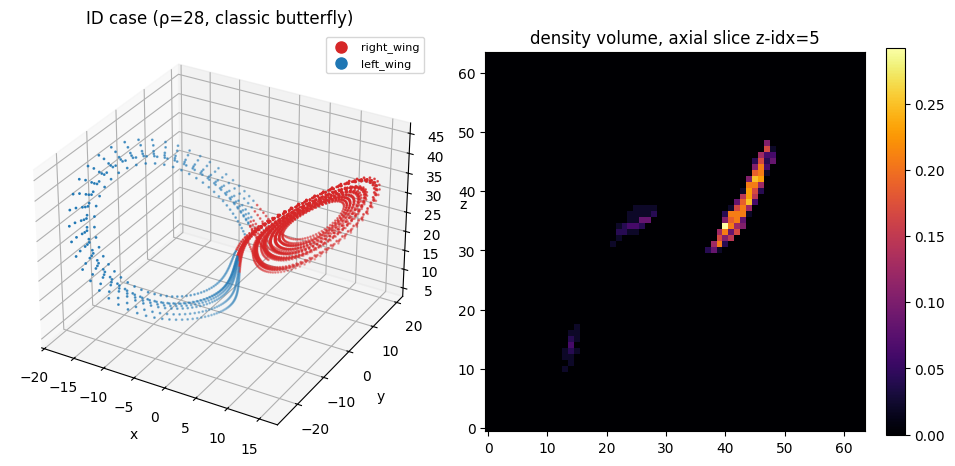

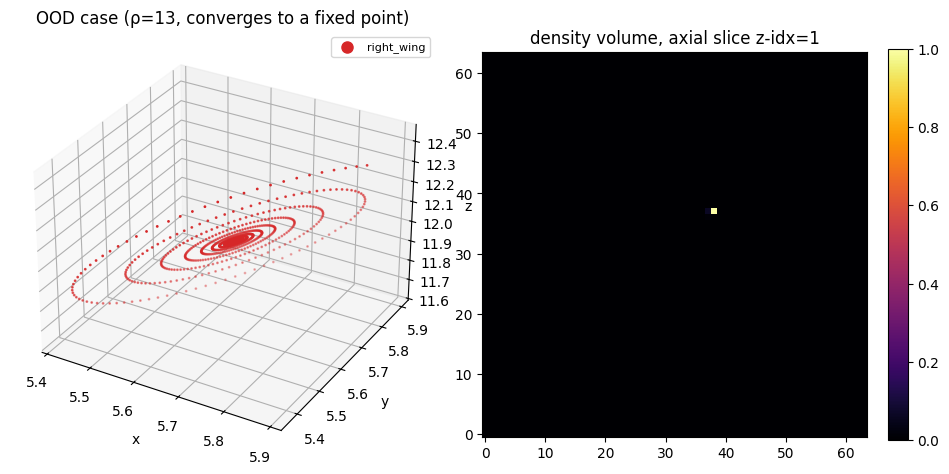

In [40]:
%matplotlib inline
density, speed_map, label, traj, idx = make_case(**ID_PARAMS, seed=0)
visualize_case(traj, idx, label, density, title='ID case (ρ=28, classic butterfly)')

density_o, speed_map_o, label_o, traj_o, idx_o = make_case(**OOD_PARAMS['fixed_point'], seed=0)
visualize_case(traj_o, idx_o, label_o, density_o, title='OOD case (ρ=13, converges to a fixed point)')

### **Training**

The models were trained in the bash using following commands (from frameworks' documentation):

`nnUNetv2_plan_and_preprocess -d 1 --verify_dataset_integrity`

`nnUNetv2_train 1 3d_fullres all -tr nnUNetTrainerDiffUMamba`

`nnUNetv2_train 1 3d_fullres all -tr nnUNetTrainerUMambaBot`

`nnUNetv2_train 1 3d_fullres all -tr nnUNetTrainer`

Training specifics are purely nnU-Net's self-configuring defaults:

- 1000 epochs per model (epoch 0 through 999, visible in every log), all three run to completion with no early stopping.
- Learning rate: nnU-Net's polynomial LR decay schedule  starting from 0.001
- `batch_dice: False`: Dice loss computed per-sample-then-averaged
- `do_dummy_2d_data_aug: True`: nnU-Net detected the data's shape was anisotropic and automatically switched to 2D-style augmentation for that axis
- Loss: nnU-Net's standard combined Dice + Cross-Entropy loss

### **Evaluation**

#### Evaluate OOD

After running predictions over the never seen dataset (predict_for_all_models.sh), we can evaluate each of the models.

Each epoch logged pseudo-Dice per class, which estimates model's accuracy calculated during training on small parts of an "image". Used to monitor if the model is learning to find the structures correctly.

`dice_per_class` function computes the standard Dice similarity coefficient separately for each integer label class (fixed_point, right_wing, left_wing, transition). 

In [10]:
def dice_per_class(pred, gt, num_classes):
    dices = {}
    for c in range(num_classes):
        p = (pred == c)
        g = (gt == c)
        p_sum = p.sum()
        g_sum = g.sum()
        if p_sum == 0 and g_sum == 0:
            dices[c] = None
            continue
        intersection = np.logical_and(p, g).sum()
        dices[c] = float(2 * intersection / (p_sum + g_sum))
    return dices

`hd95_per_class` function computes the 95th-percentile Hausdorff Distance per class via medpy.

In [11]:
from medpy.metric.binary import hd95

def hd95_per_class(pred, gt, num_classes, voxelspacing=None):
    hd_scores = {}
    for c in range(num_classes):
        p = (pred == c)
        g = (gt == c)
        if p.sum() == 0 or g.sum() == 0:
            hd_scores[c] = None
            continue
        try:
            hd_scores[c] = float(hd95(p, g, voxelspacing=voxelspacing))
        except Exception:
            hd_scores[c] = None
    return hd_scores

`foreground_agreement` collapses right_wing/left_wing/transition into one generic "foreground" class to verify whether the model find the tragectory or not. It is measured as IoU between predicted-foreground and true-foreground voxel sets, plus the raw voxel-count ratio.

In [12]:
def foreground_agreement(pred, gt, background_class=0):
    """
    To verify that the model correctly find whether the voxel is a part of the trajectory
    """
    p_fg = (pred != background_class)
    g_fg = (gt != background_class)
    p_count = int(p_fg.sum())
    g_count = int(g_fg.sum())
    intersection = np.logical_and(p_fg, g_fg).sum()
    union = np.logical_or(p_fg, g_fg).sum()
    iou = float(intersection / union) if union > 0 else None
    ratio = float(p_count / g_count) if g_count > 0 else None
    return {
        'fg_iou': iou,
        'pred_fg_count': p_count,
        'gt_fg_count': g_count,
        'count_ratio': ratio,
    }

In [13]:
def evaluate_folder(pred_dir, gt_dir, label_names, file_ending='.nii.gz', voxelspacing=None):
    num_classes = len(label_names)
    pred_files = sorted(glob.glob(os.path.join(pred_dir, f'*{file_ending}')))
    per_case = {}
    per_class_dice = defaultdict(list)
    per_class_hd95 = defaultdict(list)
    fg_iou_scores = []
    count_ratios = []

    for pf in pred_files:
        case_id = os.path.basename(pf)[:-len(file_ending)]
        gt_path = os.path.join(gt_dir, case_id + file_ending)
        if not os.path.exists(gt_path):
            continue
        pred = nib.load(pf).get_fdata().astype(np.uint8)
        gt = nib.load(gt_path).get_fdata().astype(np.uint8)
        if pred.shape != gt.shape:
            continue

        dices = dice_per_class(pred, gt, num_classes)
        hds = hd95_per_class(pred, gt, num_classes, voxelspacing=voxelspacing)
        fg = foreground_agreement(pred, gt)

        per_case[case_id] = {'dice': dices, 'hd95': hds, 'foreground': fg}
        for c, d in dices.items():
            if d is not None:
                per_class_dice[c].append(d)
        for c, h in hds.items():
            if h is not None:
                per_class_hd95[c].append(h)
        if fg['fg_iou'] is not None:
            fg_iou_scores.append(fg['fg_iou'])
        if fg['count_ratio'] is not None:
            count_ratios.append(fg['count_ratio'])

    summary = {}
    for c in range(num_classes):
        dscores = per_class_dice[c]
        hscores = per_class_hd95[c]
        summary[c] = {
            'name': label_names[c],
            'mean_dice': float(np.mean(dscores)) if dscores else None,
            'n_cases_with_class_dice': len(dscores),
            'mean_hd95': float(np.mean(hscores)) if hscores else None,
            'n_cases_with_class_hd95': len(hscores),
        }
    foreground_summary = {
        'mean_fg_iou': float(np.mean(fg_iou_scores)) if fg_iou_scores else None,
        'mean_count_ratio': float(np.mean(count_ratios)) if count_ratios else None,
        'n_cases': len(fg_iou_scores),
    }
    return per_case, summary, foreground_summary

In [8]:
label_names = {0: 'background', 1: 'right_wing', 2: 'left_wing', 3: 'transition'}

datasets = {
    'ID_heldout':          'Dataset006_LorenzID_heldout',
    'OOD_fixed_point':     'Dataset002_LorenzOOD_fixed_point',
    'OOD_transient_chaos': 'Dataset003_LorenzOOD_transient_chaos',
    'OOD_large_rho_chaos': 'Dataset004_LorenzOOD_large_rho_chaos',
    'OOD_reshaped':        'Dataset005_LorenzOOD_reshaped_attractor',
}

trainers = {
    'nnUNetTrainerDiffUMamba': 'DiffUMamba',
    'nnUNetTrainerUMambaBot':  'UMambaBot',
    'nnUNetTrainer':           'nnUNet',
}

HOME = os.path.expanduser('~')

In [15]:
for trainer_class, tag in trainers.items():
    print(f"\n########## {tag} ({trainer_class}) ##########")
    results = {}
    for regime_tag, ds in datasets.items():
        pred_dir = f'{HOME}/predictions/{trainer_class}/{ds}'
        gt_dir   = f'{HOME}/nnUNet_raw/{ds}/labelsTr'
        if not os.path.isdir(pred_dir):
            print(f"  SKIP {regime_tag}: no predictions found at {pred_dir}")
            continue
        per_case, summary, fg_summary = evaluate_folder(pred_dir, gt_dir, label_names)
        results[regime_tag] = {'classes': summary, 'foreground': fg_summary}
        print(f"  === {regime_tag} ===")
        for c, s in summary.items():
            md = f"{s['mean_dice']:.4f}" if s['mean_dice'] is not None else "N/A"
            mh = f"{s['mean_hd95']:.4f}" if s['mean_hd95'] is not None else "N/A"
            print(f"    {s['name']:12s}: Dice = {md} (n={s['n_cases_with_class_dice']})   HD95 = {mh} (n={s['n_cases_with_class_hd95']})")
        print(f"    foreground IoU = {fg_summary['mean_fg_iou']:.4f}, count ratio = {fg_summary['mean_count_ratio']:.4f}")

    out_path = f'{HOME}/ood_eval_results_{tag}.json'
    with open(out_path, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"  -> saved {out_path}")


########## DiffUMamba (nnUNetTrainerDiffUMamba) ##########
  === ID_heldout ===
    background  : Dice = 1.0000 (n=30)   HD95 = 0.0000 (n=30)
    right_wing  : Dice = 0.5325 (n=30)   HD95 = 9.8972 (n=30)
    left_wing   : Dice = 0.5066 (n=30)   HD95 = 10.0294 (n=30)
    transition  : Dice = N/A (n=0)   HD95 = N/A (n=0)
    foreground IoU = 0.9988, count ratio = 0.9988
  === OOD_fixed_point ===
    background  : Dice = 1.0000 (n=40)   HD95 = 0.0000 (n=40)
    right_wing  : Dice = 0.4867 (n=34)   HD95 = 0.0941 (n=17)
    left_wing   : Dice = 0.2754 (n=23)   HD95 = 0.2020 (n=7)
    transition  : Dice = N/A (n=0)   HD95 = N/A (n=0)
    foreground IoU = 0.9454, count ratio = 0.9454
  === OOD_transient_chaos ===
    background  : Dice = 0.9999 (n=40)   HD95 = 0.0000 (n=40)
    right_wing  : Dice = 0.4364 (n=40)   HD95 = 25.2860 (n=40)
    left_wing   : Dice = 0.4162 (n=40)   HD95 = 31.8066 (n=40)
    transition  : Dice = N/A (n=0)   HD95 = N/A (n=0)
    foreground IoU = 0.9706, count ratio 

In [16]:
TRAINERS = {
    'DiffUMamba': os.path.expanduser('~/ood_eval_results_DiffUMamba.json'),
    'UMambaBot':  os.path.expanduser('~/ood_eval_results_UMambaBot.json'),
    'nnUNet':     os.path.expanduser('~/ood_eval_results_nnUNet.json'),
}

REGIME_ORDER = ['ID_heldout', 'OOD_fixed_point', 'OOD_transient_chaos', 'OOD_large_rho_chaos', 'OOD_reshaped']
REGIME_LABELS = {
    'ID_heldout': 'ID\nheld-out',
    'OOD_fixed_point': 'OOD\nfixed point',
    'OOD_transient_chaos': 'OOD\ntransient chaos',
    'OOD_large_rho_chaos': 'OOD\nlarge ρ chaos',
    'OOD_reshaped': 'OOD\nreshaped attractor',
}
FOREGROUND_CLASS_IDS = ['1', '2', '3']

In [24]:
def load_all():
    data = {}
    for trainer, path in TRAINERS.items():
        with open(path) as f:
            data[trainer] = json.load(f)
    return data

In [61]:
def _bar_group(ax, data, trainers, metric_fn, ylabel, title):
    x = np.arange(len(REGIME_ORDER))
    width = 0.8 / len(trainers)
    colors = ['indigo', 'darkorange', 'dodgerblue']
    
    for i, tr in enumerate(trainers):
        vals = [metric_fn(data[tr].get(reg)) for reg in REGIME_ORDER]
        vals_plot = [v if v is not None else 0 for v in vals]
        bars = ax.bar(x + i * width - 0.4 + width / 2, vals_plot, width, label=tr, color=colors[i])
        for b, v in zip(bars, vals):
            label = f"{v:.1f}" if v is not None and v > 3 else (f"{v:.2f}" if v is not None else "N/A")
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(), label,
                     ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels([REGIME_LABELS[r] for r in REGIME_ORDER], fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12, fontproperties='monospace', fontweight = "bold")
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.grid(axis='y', alpha=0.3)

def full_metric_grid(data, path):
    trainers = list(data.keys())
    fig = plt.figure(figsize=(15, 13))
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1])

    ax_fgi = fig.add_subplot(gs[0, :])
    ax_dice_rw = fig.add_subplot(gs[1, 0])
    ax_dice_lw = fig.add_subplot(gs[1, 1])
    ax_hd_rw = fig.add_subplot(gs[2, 0])
    ax_hd_lw = fig.add_subplot(gs[2, 1])

    fgi_fn = lambda rs: rs['foreground']['mean_fg_iou'] if rs else None
    _bar_group(ax_fgi, data, trainers, fgi_fn, 'Foreground IoU', 'Foreground IoU')

    dice_rw = lambda rs: rs['classes']['1']['mean_dice'] if rs else None
    dice_lw = lambda rs: rs['classes']['2']['mean_dice'] if rs else None
    _bar_group(ax_dice_rw, data, trainers, dice_rw, 'right_wing Dice', 'right_wing Dice')
    _bar_group(ax_dice_lw, data, trainers, dice_lw, 'left_wing Dice', 'left_wing Dice')

    hd_rw = lambda rs: rs['classes']['1']['mean_hd95'] if rs else None
    hd_lw = lambda rs: rs['classes']['2']['mean_hd95'] if rs else None
    _bar_group(ax_hd_rw, data, trainers, hd_rw, 'right_wing HD95', 'right_wing HD95')
    _bar_group(ax_hd_lw, data, trainers, hd_lw, 'left_wing HD95', 'left_wing HD95')

    ax_fgi.legend(title='Trainer', fontsize=8, loc='lower left')
    fig.suptitle('Detection (fg IoU) | identity accuracy (Dice) | boundary distance (HD95)\n', fontsize=16, fontweight ="bold")
    fig.patch.set_facecolor('xkcd:mint green')
    plt.tight_layout()
    plt.show()
    fig.savefig(path, dpi=150)
    return path

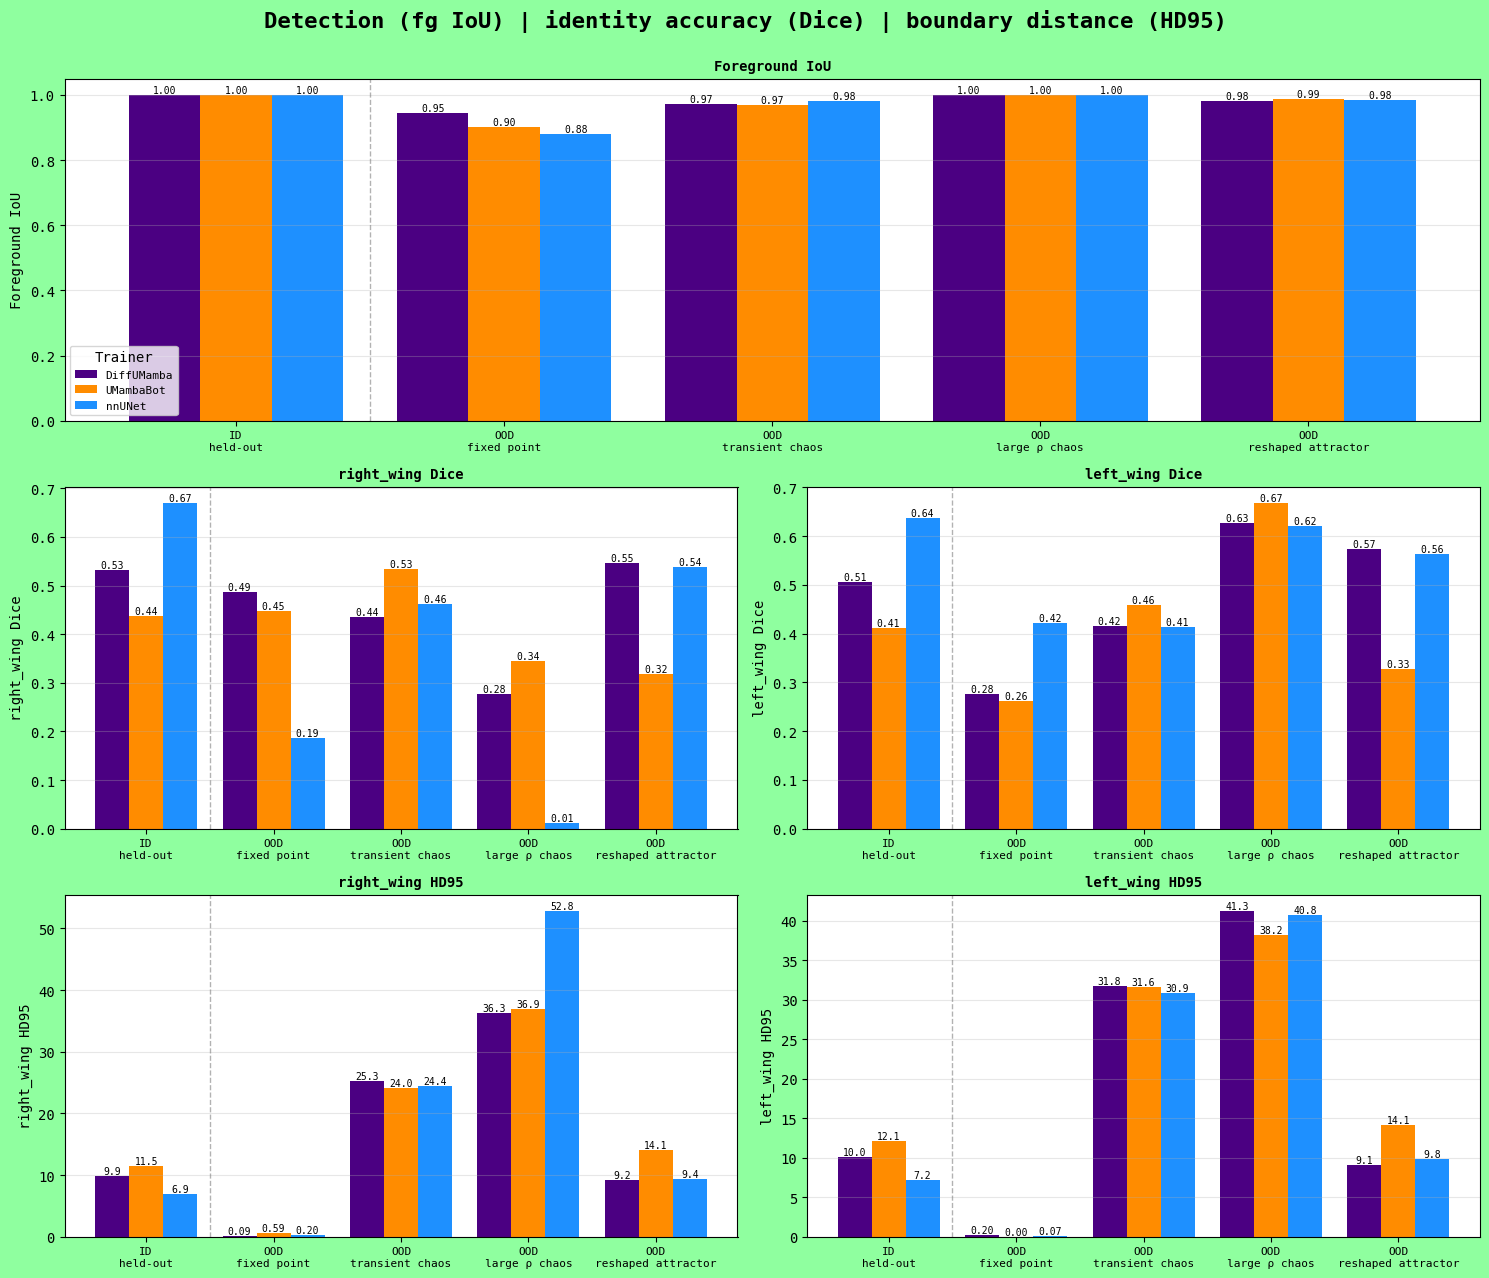

'/home/ubuntu/full_metric_grid.png'

In [62]:
%matplotlib inline
data = load_all()
full_metric_grid(data, os.path.expanduser('~/full_metric_grid.png'))

- **Foreground IoU:** near-perfect for all. Meaning that each model detects trajectory perfectly. (Could be due to the simplicity of the trajectory)

- **Per-Class Dice:** Firsly, we can see that nnU-Net performs better in the in-distribution regime. right_wing Dice collapses (0.01–0.34 depending on architecture) while left_wing Dice stays comparatively high (0.53–0.67) in the same large $\rho$ chaos regime, for every architecture. As per fixed point regime, in the left_wing Dice, the nnU-Net outperforms Mamba-based architectures. No other OOD regime shows this class-specific asymmetry.

- **HD95:** Confirms the same findings above.

Now we need to understand why there is an asymmetry in left and right wing predictions at the large $\rho$ regime.

In [65]:
ds = 'Dataset004_LorenzOOD_large_rho_chaos'

for trainer in trainers:
    pred_files = sorted(glob.glob(f'{HOME}/predictions/{trainer}/{ds}/*.nii.gz'))[:5]  
    print(f"-----> {trainer}")
    for pf in pred_files:
        case_id = os.path.basename(pf)
        gt_path = f'{HOME}/nnUNet_raw/{ds}/labelsTr/{case_id}'
        pred = nib.load(pf).get_fdata()
        gt = nib.load(gt_path).get_fdata()
        p_vals, p_counts = np.unique(pred, return_counts=True)
        g_vals, g_counts = np.unique(gt, return_counts=True)
        print(f"{case_id}")
        print(f"  pred: {dict(zip(p_vals, p_counts))}")
        print(f"  gt:   {dict(zip(g_vals, g_counts))}")

-----> nnUNetTrainerDiffUMamba
Dataset004_LorenzOOD_large_rho_chaos_0000.nii.gz
  pred: {0.0: 261819, 1.0: 57, 2.0: 268}
  gt:   {0.0: 261818, 1.0: 162, 2.0: 164}
Dataset004_LorenzOOD_large_rho_chaos_0001.nii.gz
  pred: {0.0: 261817, 1.0: 58, 2.0: 269}
  gt:   {0.0: 261817, 1.0: 164, 2.0: 163}
Dataset004_LorenzOOD_large_rho_chaos_0002.nii.gz
  pred: {0.0: 261820, 1.0: 58, 2.0: 266}
  gt:   {0.0: 261820, 1.0: 162, 2.0: 162}
Dataset004_LorenzOOD_large_rho_chaos_0003.nii.gz
  pred: {0.0: 261819, 1.0: 57, 2.0: 268}
  gt:   {0.0: 261819, 1.0: 163, 2.0: 162}
Dataset004_LorenzOOD_large_rho_chaos_0004.nii.gz
  pred: {0.0: 261815, 1.0: 58, 2.0: 271}
  gt:   {0.0: 261815, 1.0: 165, 2.0: 164}
-----> nnUNetTrainerUMambaBot
Dataset004_LorenzOOD_large_rho_chaos_0000.nii.gz
  pred: {0.0: 261818, 1.0: 62, 2.0: 264}
  gt:   {0.0: 261818, 1.0: 162, 2.0: 164}
Dataset004_LorenzOOD_large_rho_chaos_0001.nii.gz
  pred: {0.0: 261817, 1.0: 54, 2.0: 273}
  gt:   {0.0: 261817, 1.0: 164, 2.0: 163}
Dataset004_Lore

In [82]:
def confusion_status(pred, gt):
    """
    Per-voxel outcome, restricted to voxels that are true foreground (right_wing
    or left_wing) in the ground truth. Six mutually exclusive outcomes.
    """
    status = np.full(gt.shape, -1, dtype=int)
    gt1, gt2 = (gt == 1), (gt == 2)
    status[gt1 & (pred == 1)] = 0   # right_wing correct
    status[gt1 & (pred == 2)] = 1   # right_wing -> left_wing
    status[gt1 & (pred == 0)] = 2   # right_wing -> missed entirely
    status[gt2 & (pred == 2)] = 3   # left_wing correct
    status[gt2 & (pred == 1)] = 4   # left_wing -> right_wing
    status[gt2 & (pred == 0)] = 5   # left_wing -> missed entirely
    return status

In [83]:
LABELS = {0: 'right_wing correct', 1: 'right_wing->left_wing', 2: 'right_wing->missed',
          3: 'left_wing correct',  4: 'left_wing->right_wing', 5: 'left_wing->missed'}
COLORS = {0: 'tab:green', 1: 'orange', 2: 'red', 3: 'tab:green', 4: 'orange', 5: 'red'}

In [84]:
def plot_confusion_3d(pred_path, gt_path, title=''):
    pred = nib.load(pred_path).get_fdata()
    gt = nib.load(gt_path).get_fdata()
    status = confusion_status(pred, gt)

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')
    for code, name in LABELS.items():
        idx = np.argwhere(status == code)
        if len(idx) == 0:
            continue
        ax.scatter(idx[:,0], idx[:,1], idx[:,2], s=10, color=COLORS[code],
                    label=f'{name} (n={len(idx)})')
    ax.set_xlabel('voxel x'); ax.set_ylabel('voxel y'); ax.set_zlabel('voxel z')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

    print(f"\n--- {title} ---")
    for code, name in LABELS.items():
        print(f"  {name}: {(status==code).sum()}")

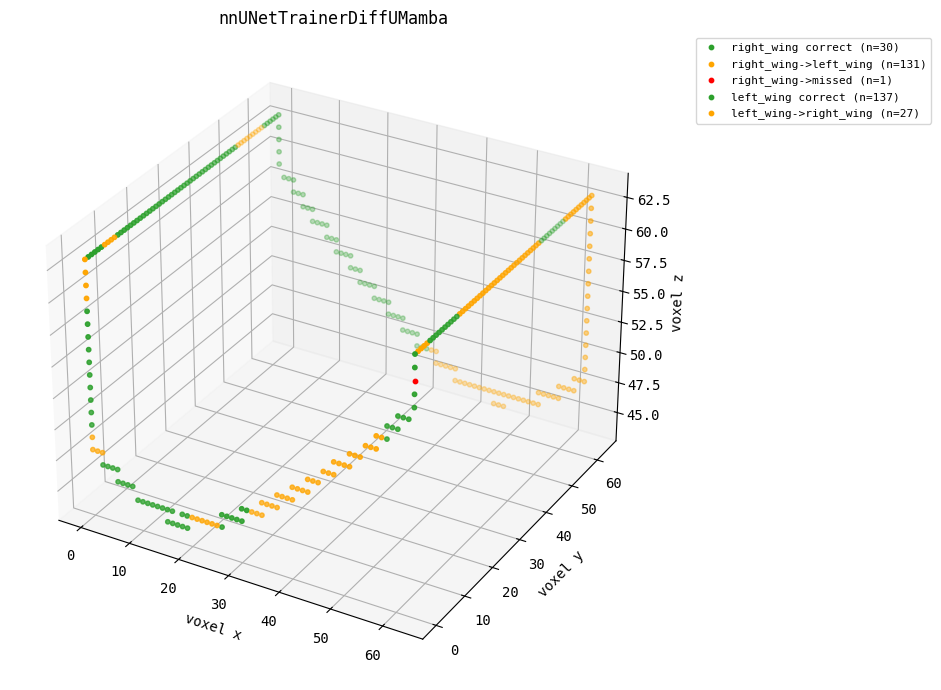


--- nnUNetTrainerDiffUMamba ---
  right_wing correct: 30
  right_wing->left_wing: 131
  right_wing->missed: 1
  left_wing correct: 137
  left_wing->right_wing: 27
  left_wing->missed: 0


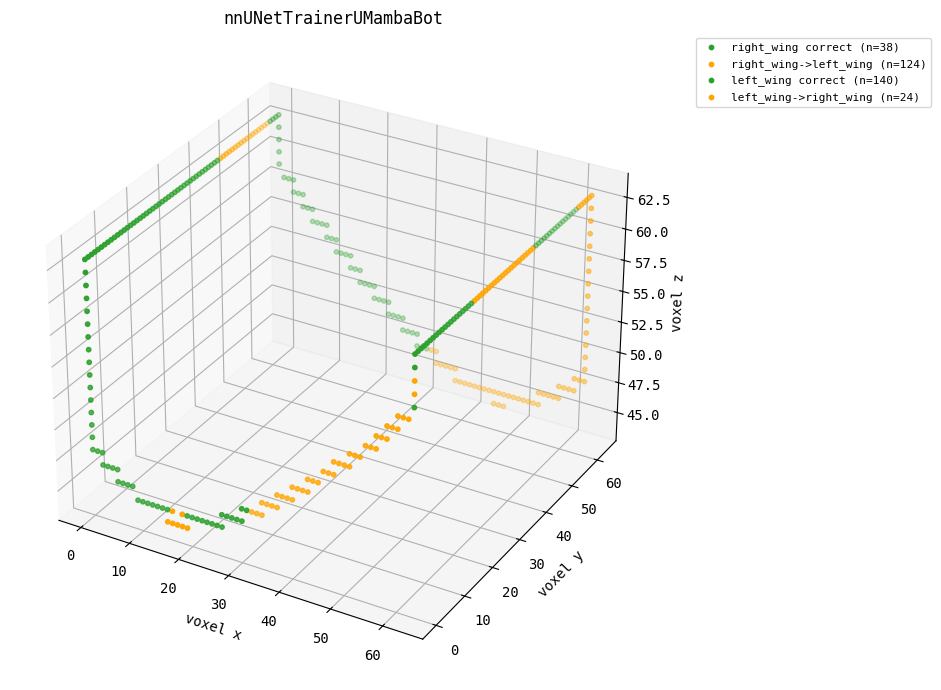


--- nnUNetTrainerUMambaBot ---
  right_wing correct: 38
  right_wing->left_wing: 124
  right_wing->missed: 0
  left_wing correct: 140
  left_wing->right_wing: 24
  left_wing->missed: 0


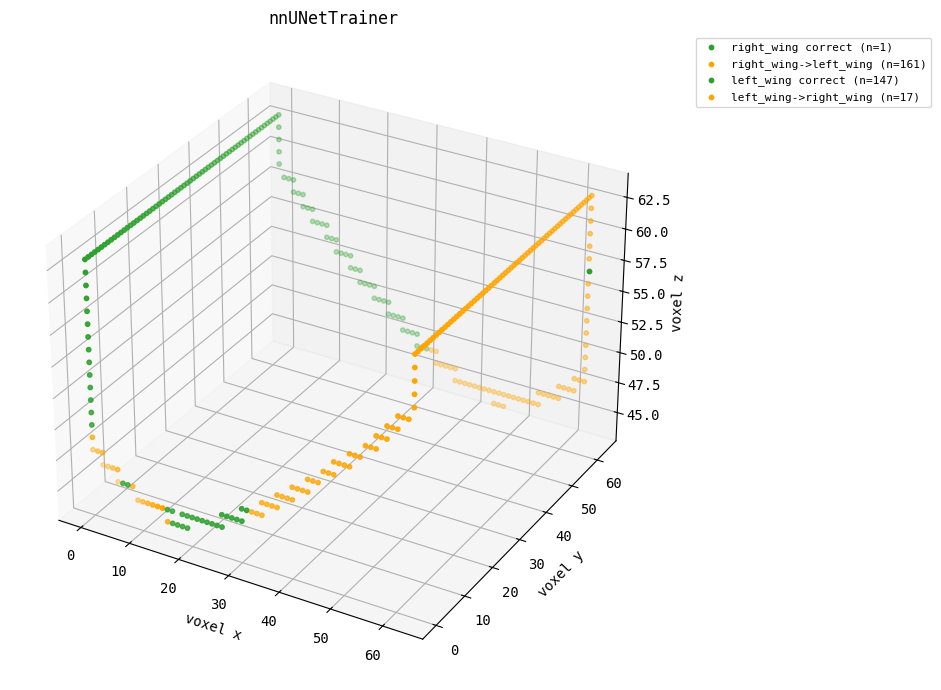


--- nnUNetTrainer ---
  right_wing correct: 1
  right_wing->left_wing: 161
  right_wing->missed: 0
  left_wing correct: 147
  left_wing->right_wing: 17
  left_wing->missed: 0


In [89]:
HOME = os.path.expanduser('~')
ds = 'Dataset004_LorenzOOD_large_rho_chaos'
case = 'Dataset004_LorenzOOD_large_rho_chaos_0000.nii.gz'
gt_path = f'{HOME}/nnUNet_raw/{ds}/labelsTr/{case}'

for trainer in ['nnUNetTrainerDiffUMamba', 'nnUNetTrainerUMambaBot', 'nnUNetTrainer']:
    pred_path = f'{HOME}/predictions/{trainer}/{ds}/{case}'
    plot_confusion_3d(pred_path, gt_path, title=trainer)

In [122]:
def mean_foreground_dice(regime_summary):
    classes = regime_summary['classes']
    vals = [classes[c]['mean_dice'] for c in FOREGROUND_CLASS_IDS
             if c in classes and classes[c]['mean_dice'] is not None]
    return float(np.mean(vals)) if vals else None
def mean_fg_iou(regime_summary):
    return regime_summary['foreground']['mean_fg_iou']

In [123]:
def build_summary_rows(data):
    rows = []
    for trainer, results in data.items():
        for regime in REGIME_ORDER:
            if regime not in results:
                continue
            rs = results[regime]
            rows.append([trainer, regime, mean_foreground_dice(rs), mean_fg_iou(rs)])
    return rows

In [130]:
def two_panel_plot(rows, path):
    trainers = list(dict.fromkeys(r[0] for r in rows))
    lookup = {(r[0], r[1]): (r[2], r[3]) for r in rows}
    x = np.arange(len(REGIME_ORDER))
    width = 0.8 / len(trainers)
    colors=colors = ['indigo', 'darkorange', 'dodgerblue']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for ax, metric_idx, title in [
        (axes[0], 1, 'Foreground IoU'),
        (axes[1], 0, 'Mean wing Dice'),
    ]:
        for i, tr in enumerate(trainers):
            vals = [lookup.get((tr, reg), (None, None))[metric_idx] for reg in REGIME_ORDER]
            vals_plot = [v if v is not None else 0 for v in vals]
            bars = ax.bar(x + i * width - 0.4 + width / 2, vals_plot, width, label=tr, color=colors[i])
            for b, v in zip(bars, vals):
                label = f"{v:.2f}" if v is not None else "N/A"
                ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01, label,
                         ha='center', va='bottom', fontsize=7, rotation=90)
        ax.set_xticks(x)
        ax.set_xticklabels([REGIME_LABELS[r] for r in REGIME_ORDER], fontsize=9, fontproperties='monospace')
        ax.set_title(title)
        ax.set_ylim(0, 1.08)
        ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
        ax.grid(axis='y', alpha=0.3)

    axes[0].set_ylabel('Score')
    axes[0].legend(title='Trainer', loc='lower left', fontsize=8)
    fig.suptitle('Comparison of trajectory detection and wing-identity accuracy', fontsize=16, fontweight='bold')
    fig.patch.set_facecolor('xkcd:mint green')
    plt.tight_layout()
    plt.show()
    fig.savefig(path, dpi=150)
    return path

In [131]:
def large_rho_highlight_table(data, path):
    regime = 'OOD_large_rho_chaos'
    lines = ["------------------------------------------------------------------",
             "| Trainer    | right_wing Dice | left_wing Dice | foreground IoU |",
             "|------------|-----------------|----------------|----------------|"]
    for trainer, results in data.items():
        if regime not in results:
            continue
        classes = results[regime]['classes']
        rw = classes.get('1', {}).get('mean_dice')
        lw = classes.get('2', {}).get('mean_dice')
        fgi = results[regime]['foreground']['mean_fg_iou']
        rw_s = f"{rw:.4f}" if rw is not None else "N/A"
        lw_s = f"{lw:.4f}" if lw is not None else "N/A"
        fgi_s = f"{fgi:.4f}" if fgi is not None else "N/A"
        lines.append(f"| {trainer}| {rw_s}           | {lw_s}         | {fgi_s}         |")
    table = "\n".join(lines)
    #print(table)
    with open(path, 'w') as f:
        f.write(table)
    return table

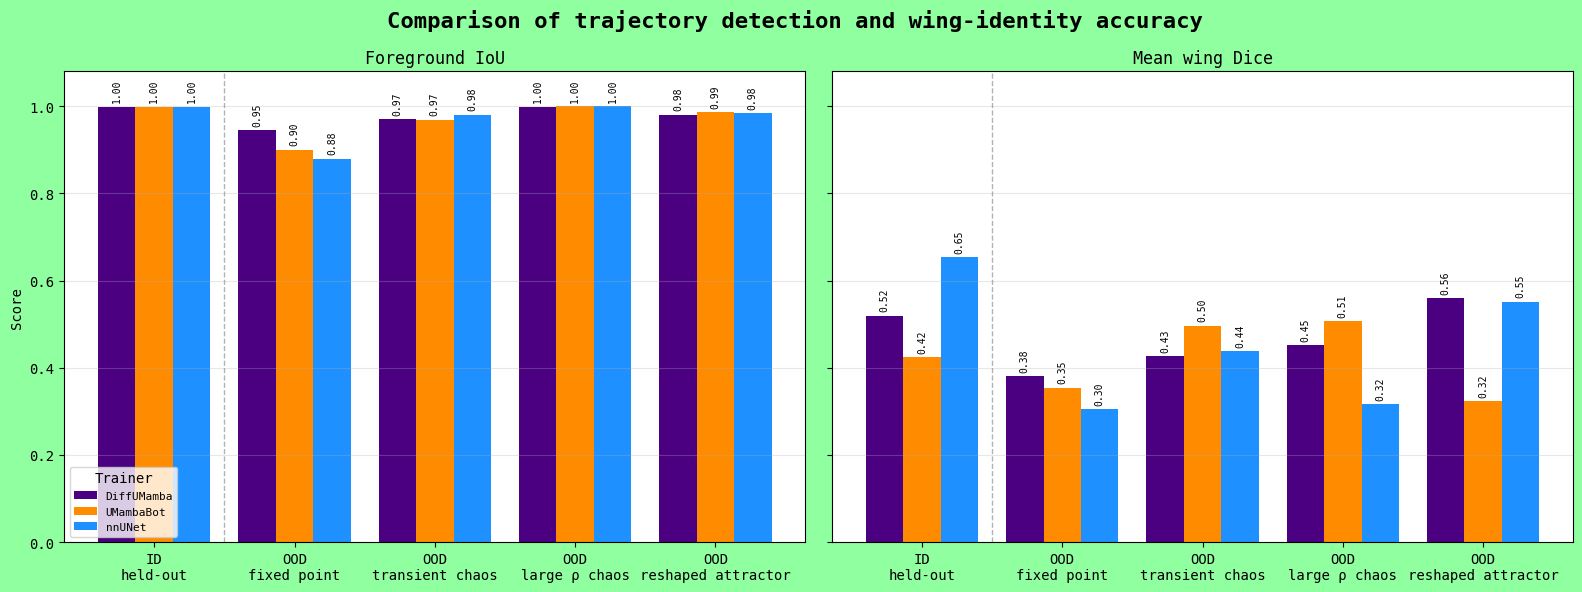

'/home/ubuntu/ood_comparison_plot_64grid.png'

In [133]:
matplotlib.use('Agg')
%matplotlib inline

two_panel_plot(rows, os.path.expanduser(f'~/ood_comparison_plot_{GRID}grid.png'))

In [135]:
data = load_all()
rows = build_summary_rows(data)

print("Large ρ chaos regime:")
hl = large_rho_highlight_table(data, os.path.expanduser(f'~/large_rho_highlight_{GRID}grid.md'))
print(hl)

Large ρ chaos regime:
------------------------------------------------------------------
| Trainer    | right_wing Dice | left_wing Dice | foreground IoU |
|------------|-----------------|----------------|----------------|
| DiffUMamba| 0.2770           | 0.6276         | 0.9993         |
| UMambaBot| 0.3442           | 0.6680         | 1.0000         |
| nnUNet| 0.0111           | 0.6211         | 1.0000         |


All architectures fail at the left and right wing prediction in the large $\rho$ regime, however, the Mamba-based ones are slightly better. *(Would be nice to verify with different seeds)*

### **Verification NRM's impact**

In [9]:
from nnunetv2.utilities.plans_handling.plans_handler import PlansManager
from nnunetv2.paths import nnUNet_preprocessed

CHECKPOINT = os.path.expanduser(
    "~/nnUNet_results/Dataset001_LorenzID/nnUNetTrainerDiffUMamba__nnUNetPlans__3d_fullres/fold_all/checkpoint_best.pth"
)

ckpt = torch.load(CHECKPOINT, map_location='cpu', weights_only=False)
state_dict = ckpt['network_weights']

for name, tensor in state_dict.items():
    lname = name.lower()
    if any(k in lname for k in ['lambda', 'lam', 'nrm', 'noise', 'diff']):
        print(f"{name:60s} shape={tuple(tensor.shape)}")

prefixes = set()
for name in state_dict.keys():
    parts = name.split('.')
    prefixes.add('.'.join(parts[:2]))
print("\n\n")
for p in sorted(prefixes):
    print(p)

print("\n\n")
for name, tensor in state_dict.items():
    if 'mamba_m_1' in name or 'mamba_m_2' in name:
        print(f"{name:60s} shape={tuple(tensor.shape)}")

lambdas                                                      shape=(3,)



decoder.encoder
decoder.seg_layers
decoder.stages
decoder.upsample_layers
encoder.stages
encoder.stem
lambdas
mamba_m_1.mamba
mamba_m_1.norm
mamba_m_2.mamba
mamba_m_2.norm
proj_convs.0
proj_convs.1
proj_convs.2



mamba_m_1.norm.weight                                        shape=(256,)
mamba_m_1.norm.bias                                          shape=(256,)
mamba_m_1.mamba.A_log                                        shape=(512, 16)
mamba_m_1.mamba.D                                            shape=(512,)
mamba_m_1.mamba.in_proj.weight                               shape=(1024, 256)
mamba_m_1.mamba.conv1d.weight                                shape=(512, 1, 4)
mamba_m_1.mamba.conv1d.bias                                  shape=(512,)
mamba_m_1.mamba.x_proj.weight                                shape=(48, 512)
mamba_m_1.mamba.dt_proj.weight                               shape=(512, 16)
mamba_m_1.mamba.dt_proj.bi

In [10]:
!sed -n '/class DiffUMamba/,/^class /p' ~/DiffUMamba-Official/nnunetv2/nets/DiffUMamba.py | head -150

class DiffUMamba(nn.Module):
    def __init__(self,
                 input_channels: int,
                 n_stages: int,
                 features_per_stage: Union[int, List[int], Tuple[int, ...]],
                 conv_op: Type[_ConvNd],
                 kernel_sizes: Union[int, List[int], Tuple[int, ...]],
                 strides: Union[int, List[int], Tuple[int, ...]],
                 n_conv_per_stage: Union[int, List[int], Tuple[int, ...]],
                 num_classes: int,
                 n_conv_per_stage_decoder: Union[int, Tuple[int, ...], List[int]],
                 conv_bias: bool = False,
                 norm_op: Union[None, Type[nn.Module]] = None,
                 norm_op_kwargs: dict = None,
                 dropout_op: Union[None, Type[_DropoutNd]] = None,
                 dropout_op_kwargs: dict = None,
                 nonlin: Union[None, Type[torch.nn.Module]] = None,
                 nonlin_kwargs: dict = None,
                 deep_supervision: bool = False,
 

In [11]:
from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor

def make_hook(key):
    def hook(module, inputs, output):
        captured[key].append(output.detach().cpu())
    return hook

def analyze_case(image_files, label):
    captured['m1'].clear()
    captured['m2'].clear()
    predictor.predict_from_files(
        [image_files], f'/tmp/nrm_probe_out_{label}',
        save_probabilities=False, overwrite=True,
        num_processes_preprocessing=1, num_processes_segmentation_export=1
    )
    m1 = torch.cat([x.flatten(2) for x in captured['m1']], dim=0)  # (n_patches, C, N)
    m2 = torch.cat([x.flatten(2) for x in captured['m2']], dim=0)
    m_hat = m1 - m2

    m1_norm = m1.norm(dim=1).mean().item()
    m2_norm = m2.norm(dim=1).mean().item()

    m1_flat = m1.flatten().numpy()
    m2_flat = m2.flatten().numpy()
    corr = np.corrcoef(m1_flat, m2_flat)[0, 1]

    print(f"\n\n-----> {label} ")
    print(f"  mean L2 norm  m1={m1_norm:.4f}  m2={m2_norm:.4f}  m_hat={m_hat.norm(dim=1).mean().item():.4f}")
    print(f"  corr(m1, m2) = {corr:.4f}")
    print("\n\n")

In [12]:
MODEL_DIR = f'./nnUNet_results/Dataset001_LorenzID/nnUNetTrainerDiffUMamba__nnUNetPlans__3d_fullres'

predictor = nnUNetPredictor(
    tile_step_size=0.5, use_gaussian=True, use_mirroring=False,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
)
predictor.initialize_from_trained_model_folder(
    MODEL_DIR, use_folds=('all',), checkpoint_name='checkpoint_final.pth'
)
network = predictor.network
network.eval()

print("lambdas:", network.lambdas.data.cpu().numpy())

captured = {'m1': [], 'm2': []}

h1 = network.mamba_m_1.register_forward_hook(make_hook('m1'))
h2 = network.mamba_m_2.register_forward_hook(make_hook('m2'))

analyze_case([f'{HOME}/nnUNet_raw/Dataset006_LorenzID_heldout/imagesTr/Dataset006_LorenzID_heldout_0000_0000.nii.gz',
              f'{HOME}/nnUNet_raw/Dataset006_LorenzID_heldout/imagesTr/Dataset006_LorenzID_heldout_0000_0001.nii.gz'],
             'ID_heldout')

analyze_case([f'{HOME}/nnUNet_raw/Dataset002_LorenzOOD_fixed_point/imagesTr/Dataset002_LorenzOOD_fixed_point_0000_0000.nii.gz',
              f'{HOME}/nnUNet_raw/Dataset002_LorenzOOD_fixed_point/imagesTr/Dataset002_LorenzOOD_fixed_point_0000_0001.nii.gz'],
             'OOD_fixed_point')

analyze_case([f'{HOME}/nnUNet_raw/Dataset003_LorenzOOD_transient_chaos/imagesTr/Dataset003_LorenzOOD_transient_chaos_0000_0000.nii.gz',
              f'{HOME}/nnUNet_raw/Dataset003_LorenzOOD_transient_chaos/imagesTr/Dataset003_LorenzOOD_transient_chaos_0000_0001.nii.gz'],
             'OOD_transient_chaos')

analyze_case([f'{HOME}/nnUNet_raw/Dataset004_LorenzOOD_large_rho_chaos/imagesTr/Dataset004_LorenzOOD_large_rho_chaos_0000_0000.nii.gz',
              f'{HOME}/nnUNet_raw/Dataset004_LorenzOOD_large_rho_chaos/imagesTr/Dataset004_LorenzOOD_large_rho_chaos_0000_0001.nii.gz'],
             'OOD_large_rho_chaos')

analyze_case([f'{HOME}/nnUNet_raw/Dataset005_LorenzOOD_reshaped_attractor/imagesTr/Dataset005_LorenzOOD_reshaped_attractor_0000_0000.nii.gz',
              f'{HOME}/nnUNet_raw/Dataset005_LorenzOOD_reshaped_attractor/imagesTr/Dataset005_LorenzOOD_reshaped_attractor_0000_0001.nii.gz'],
             'OOD_reshaped_attractor')

h1.remove()
h2.remove()

DiffUMamba: DiffUMamba(
  (encoder): UNetResEncoder(
    (stem): Sequential(
      (0): BasicResBlock(
        (conv1): Conv3d(2, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (norm1): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
        (act1): LeakyReLU(negative_slope=0.01, inplace=True)
        (conv2): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (norm2): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
        (act2): LeakyReLU(negative_slope=0.01, inplace=True)
        (conv3): Conv3d(2, 32, kernel_size=(1, 1, 1), stride=(1, 1, 1))
      )
      (1): BasicBlockD(
        (conv1): ConvDropoutNormReLU(
          (conv): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (norm): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
          (nonlin): LeakyReLU(negative_slope=0.01, in

100%|████████████████████████████████████████████| 1/1 [00:00<00:00,  3.21it/s]


sending off prediction to background worker for resampling and export
done with Dataset006_LorenzID_heldout_0000


-----> ID_heldout 
  mean L2 norm  m1=0.6026  m2=0.6625  m_hat=1.0386
  corr(m1, m2) = -0.2509



There are 1 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 1 cases that I would like to predict
resizing data, order is 3
data shape (2, 2, 2, 2)
resizing segmentation, order is 1 order z is 0
data shape (1, 2, 2, 2)

Predicting Dataset002_LorenzOOD_fixed_point_0000:
perform_everything_on_device: True


100%|████████████████████████████████████████████| 1/1 [00:00<00:00, 66.96it/s]

sending off prediction to background worker for resampling and export
done with Dataset002_LorenzOOD_fixed_point_0000


...

100%|█████████████████████████████████████████| 24/24 [00:00<00:00, 121.55it/s]


sending off prediction to background worker for resampling and export
done with Dataset004_LorenzOOD_large_rho_chaos_0000
resizing data, order is 1
data shape (4, 20, 64, 64)


-----> OOD_large_rho_chaos 
  mean L2 norm  m1=0.5851  m2=0.6201  m_hat=0.9990
  corr(m1, m2) = -0.2016



There are 1 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 1 cases that I would like to predict
resizing data, order is 3
data shape (2, 6, 33, 35)
resizing segmentation, order is 1 order z is 0
data shape (1, 6, 33, 35)

Predicting Dataset005_LorenzOOD_reshaped_attractor_0000:
perform_everything_on_device: True


100%|████████████████████████████████████████████| 1/1 [00:00<00:00, 69.50it/s]

sending off prediction to background worker for resampling and export
done with Dataset005_LorenzOOD_reshaped_attractor_0000


resizing data, order is 1
data shape (4, 6, 33, 35)


-----> OOD_reshaped_attractor 
  mean L2 norm  m1=0.5219  m2=0.7201  m_hat=0.9997
  corr(m1, m2) = -0.2255





In [13]:
def analyze_regime(dataset_name, label, n_cases=8):
    img_dir = f'{HOME}/nnUNet_raw/{dataset_name}/imagesTr'
    channel0_files = sorted(glob.glob(f'{img_dir}/*_0000.nii.gz'))[:n_cases]

    case_stats = []
    for c0 in channel0_files:
        c1 = c0.replace('_0000.nii.gz', '_0001.nii.gz')
        captured['m1'].clear()
        captured['m2'].clear()
        predictor.predict_from_files(
            [[c0, c1]], f'/tmp/nrm_probe_out_{label}',
            save_probabilities=False, overwrite=True,
            num_processes_preprocessing=1, num_processes_segmentation_export=1
        )
        m1 = torch.cat([x.flatten(2) for x in captured['m1']], dim=0)
        m2 = torch.cat([x.flatten(2) for x in captured['m2']], dim=0)
        m1_norm = m1.norm(dim=1).mean().item()
        m2_norm = m2.norm(dim=1).mean().item()
        corr = np.corrcoef(m1.flatten().numpy(), m2.flatten().numpy())[0, 1]
        case_stats.append((m1_norm, m2_norm, corr))

    arr = np.array(case_stats)  # (n_cases, 3)
    print(f"\n\n----> {label}  (n={len(case_stats)} cases)")
    print(f"  m1_norm: mean={arr[:,0].mean():.4f}  std={arr[:,0].std():.4f}")
    print(f"  m2_norm: mean={arr[:,1].mean():.4f}  std={arr[:,1].std():.4f}")
    print(f"  m2/m1 ratio: mean={ (arr[:,1]/arr[:,0]).mean():.4f}")
    print(f"  corr(m1,m2): mean={arr[:,2].mean():.4f}  std={arr[:,2].std():.4f}\n\n")
    return arr

In [14]:
predictor = nnUNetPredictor(
    tile_step_size=0.5, use_gaussian=True, use_mirroring=False,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
)
predictor.initialize_from_trained_model_folder(
    MODEL_DIR, use_folds=('all',), checkpoint_name='checkpoint_final.pth'
)

network = predictor.network
network.eval()
print("lambdas:", network.lambdas.data.cpu().numpy())

captured = {'m1': [], 'm2': []}

h1 = network.mamba_m_1.register_forward_hook(make_hook('m1'))
h2 = network.mamba_m_2.register_forward_hook(make_hook('m2'))

results = {}
results['ID_heldout']          = analyze_regime('Dataset006_LorenzID_heldout', 'ID_heldout')
results['OOD_fixed']           = analyze_regime('Dataset002_LorenzOOD_fixed_point', 'OOD_fixed')
results['OOD_transient']       = analyze_regime('Dataset003_LorenzOOD_transient_chaos', 'OOD_transient')
results['OOD_large_rho_chaos'] = analyze_regime('Dataset004_LorenzOOD_large_rho_chaos', 'OOD_large_rho_chaos')
results['OOD_reshaped']        = analyze_regime('Dataset005_LorenzOOD_reshaped_attractor', 'OOD_reshaped')

h1.remove()
h2.remove()

DiffUMamba: DiffUMamba(
  (encoder): UNetResEncoder(
    (stem): Sequential(
      (0): BasicResBlock(
        (conv1): Conv3d(2, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (norm1): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
        (act1): LeakyReLU(negative_slope=0.01, inplace=True)
        (conv2): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (norm2): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
        (act2): LeakyReLU(negative_slope=0.01, inplace=True)
        (conv3): Conv3d(2, 32, kernel_size=(1, 1, 1), stride=(1, 1, 1))
      )
      (1): BasicBlockD(
        (conv1): ConvDropoutNormReLU(
          (conv): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (norm): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
          (nonlin): LeakyReLU(negative_slope=0.01, in

100%|████████████████████████████████████████████| 1/1 [00:00<00:00, 68.82it/s]

sending off prediction to background worker for resampling and export
done with Dataset006_LorenzID_heldout_0000


resizing data, order is 1
data shape (4, 8, 44, 39)
There are 1 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 1 cases that I would like to predict
resizing data, order is 3
data shape (2, 8, 43, 38)
resizing segmentation, order is 1 order z is 0
data shape (1, 8, 43, 38)

Predicting Dataset006_LorenzID_heldout_0001:
perform_everything_on_device: True


100%|████████████████████████████████████████████| 1/1 [00:00<00:00, 68.05it/s]

...

sending off prediction to background worker for resampling and export
done with Dataset005_LorenzOOD_reshaped_attractor_0006


resizing data, order is 1
data shape (4, 7, 36, 37)
There are 1 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 1 cases that I would like to predict
resizing data, order is 3
data shape (2, 6, 33, 35)
resizing segmentation, order is 1 order z is 0
data shape (1, 6, 33, 35)

Predicting Dataset005_LorenzOOD_reshaped_attractor_0007:
perform_everything_on_device: True


100%|████████████████████████████████████████████| 1/1 [00:00<00:00, 69.63it/s]

sending off prediction to background worker for resampling and export
done with Dataset005_LorenzOOD_reshaped_attractor_0007


resizing data, order is 1
data shape (4, 6, 33, 35)


----> OOD_reshaped  (n=8 cases)
  m1_norm: mean=0.5839  std=0.0431
  m2_norm: mean=0.7221  std=0.0089
  m2/m1 ratio: mean=1.2435
  corr(m1,m2): mean=-0.1998  std=0.0423




In [20]:
def plot_nrm_summary(results):
    labels = list(results.keys())
    ratio_mean, ratio_std, corr_mean, corr_std = [], [], [], []
    for lab in labels:
        arr = results[lab]
        ratios = arr[:, 1] / arr[:, 0]
        ratio_mean.append(ratios.mean()); ratio_std.append(ratios.std())
        corr_mean.append(arr[:, 2].mean()); corr_std.append(arr[:, 2].std())

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    x = np.arange(len(labels))

    axes[0].bar(x, ratio_mean, yerr=ratio_std, capsize=4, color='tab:orange')
    axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=1)
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=30, ha='right')
    axes[0].set_ylabel('m2 / m1 norm ratio')
    axes[0].set_title('NRM noise/signal ratio')
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].bar(x, corr_mean, yerr=corr_std, capsize=4, color='tab:purple')
    axes[1].axhline(0.0, color='gray', linestyle='--', linewidth=1)
    axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=30, ha='right')
    axes[1].set_ylabel('corr(m1, m2)')
    axes[1].set_title('Signal/noise decorrelation')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

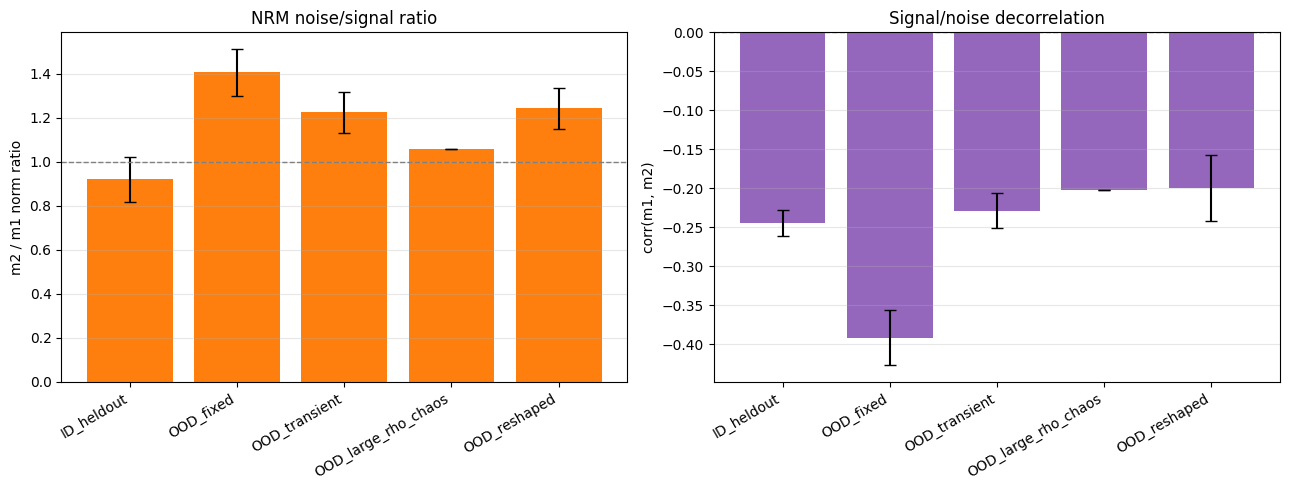

In [23]:
%matplotlib inline
plot_nrm_summary(results)